<a href="https://colab.research.google.com/github/Cthiare/Intro-to-Deep-Learning/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR 4106/5106 — Intro to Deep Learning
## Homework 3 — Sequence-to-Sequence Machine Translation


## Setup

In [1]:
import os, re, time, random
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42; random.seed(SEED); torch.manual_seed(SEED)
SOS, EOS = 0, 1
smooth = SmoothingFunction().method4
print("Device:", device)

# hyperparameters
HIDDEN = 256
EPOCHS = 50
LR = 1e-3
TF_RATIO = 0.5
DROPOUT = 0.1

Device: cuda


In [2]:
if not os.path.exists("vast_english_french.txt"):
    from google.colab import files
    files.upload()   # select vast_english_french.txt

Saving vast_english_french.txt to vast_english_french.txt


In [3]:
def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?,])", r" \1 ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

pairs = []
with open("vast_english_french.txt", encoding="utf-8") as f:
    for line in f:
        if "\t" not in line: continue
        en, fr = line.rstrip("\n").split("\t")
        pairs.append((normalize(en), normalize(fr)))

random.shuffle(pairs)
n_train = int(0.8 * len(pairs))
train_pairs, val_pairs = pairs[:n_train], pairs[n_train:]
MAX_LENGTH = max(max(len(a.split()), len(b.split())) for a, b in pairs) + 1
print(f"pairs: {len(pairs)} | train: {len(train_pairs)} | val: {len(val_pairs)} "
      f"| MAX_LENGTH: {MAX_LENGTH}")

pairs: 555 | train: 444 | val: 111 | MAX_LENGTH: 15


In [4]:
class Lang:
    def __init__(self):
        self.w2i = {"SOS": SOS, "EOS": EOS}
        self.i2w = {SOS: "SOS", EOS: "EOS"}
        self.n = 2
    def add(self, sentence):
        for w in sentence.split(" "):
            if w not in self.w2i:
                self.w2i[w] = self.n; self.i2w[self.n] = w; self.n += 1

def view(direction):
    # returns (train, val) lists of (source_sentence, target_sentence)
    if direction == "en-fr":
        return train_pairs[:], val_pairs[:]
    return [(b, a) for a, b in train_pairs], [(b, a) for a, b in val_pairs]

def build_vocab(train):
    src_lang, tgt_lang = Lang(), Lang()
    for s, t in train:
        src_lang.add(s); tgt_lang.add(t)
    return src_lang, tgt_lang

def to_ids(lang, sentence):
    return [lang.w2i.get(w, EOS) for w in sentence.split(" ")] + [EOS]

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    def forward(self, x, h):
        out = self.embedding(x).view(1, 1, -1)
        out, h = self.gru(out, h)
        return out, h
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
    def forward(self, x, h, encoder_outputs=None):
        out = F.relu(self.embedding(x).view(1, 1, -1))
        out, h = self.gru(out, h)
        out = F.log_softmax(self.out(out[0]), dim=1)
        return out, h, None

class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, max_length, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size; self.max_length = max_length
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attn = nn.Linear(hidden_size * 2, max_length)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
    def forward(self, x, h, encoder_outputs):
        emb = self.dropout(self.embedding(x).view(1, 1, -1))
        attn_w = F.softmax(self.attn(torch.cat((emb[0], h[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_w.unsqueeze(0), encoder_outputs.unsqueeze(0))
        out = self.attn_combine(torch.cat((emb[0], attn_applied[0]), 1)).unsqueeze(0)
        out, h = self.gru(F.relu(out), h)
        out = F.log_softmax(self.out(out[0]), dim=1)
        return out, h, attn_w

## Training and evaluation helpers

In [6]:
def run_sentence(enc, dec, src_ids, tgt_ids, criterion, train):
    h = enc.initHidden()
    enc_outputs = torch.zeros(MAX_LENGTH, enc.hidden_size, device=device)
    src = torch.tensor(src_ids, device=device)
    for i in range(len(src_ids)):
        o, h = enc(src[i], h); enc_outputs[i] = o[0, 0]
    dec_in = torch.tensor([SOS], device=device)
    tgt = torch.tensor(tgt_ids, device=device)
    use_tf = train and random.random() < TF_RATIO
    loss = 0
    for di in range(len(tgt_ids)):
        o, h, _ = dec(dec_in, h, enc_outputs)
        loss = loss + criterion(o, tgt[di:di+1])
        top1 = o.argmax(1)
        dec_in = tgt[di:di+1] if use_tf else top1.detach()
        if top1.item() == EOS and not use_tf:
            break
    return loss, len(tgt_ids)

@torch.no_grad()
def translate(enc, dec, src_lang, tgt_lang, sentence):
    src_ids = to_ids(src_lang, sentence)
    h = enc.initHidden()
    enc_outputs = torch.zeros(MAX_LENGTH, enc.hidden_size, device=device)
    src = torch.tensor(src_ids, device=device)
    for i in range(len(src_ids)):
        o, h = enc(src[i], h); enc_outputs[i] = o[0, 0]
    dec_in = torch.tensor([SOS], device=device)
    words, attns = [], []
    for _ in range(MAX_LENGTH):
        o, h, aw = dec(dec_in, h, enc_outputs)
        if aw is not None: attns.append(aw[0].cpu().tolist())
        top1 = o.argmax(1).item()
        if top1 == EOS: break
        words.append(tgt_lang.i2w.get(top1, "?"))
        dec_in = torch.tensor([top1], device=device)
    return words, attns

@torch.no_grad()
def val_loss(enc, dec, val, src_lang, tgt_lang, criterion):
    tot = 0.0
    for s, t in val:
        l, n = run_sentence(enc, dec, to_ids(src_lang, s), to_ids(tgt_lang, t),
                            criterion, train=False)
        tot += l.item() / n
    return tot / len(val)

def evaluate(enc, dec, val, src_lang, tgt_lang):
    refs, hyps, exact = [], [], 0
    for s, t in val:
        pred, _ = translate(enc, dec, src_lang, tgt_lang, s)
        tgt_words = t.split(" ")
        hyps.append(pred); refs.append([tgt_words])
        if pred == tgt_words: exact += 1
    bleu = corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25),
                       smoothing_function=smooth)
    return exact / len(val), bleu

def train_model(attn, direction, epochs=EPOCHS, label=""):
    train, val = view(direction)
    src_lang, tgt_lang = build_vocab(train)
    enc = Encoder(src_lang.n, HIDDEN).to(device)
    dec = (AttnDecoder(HIDDEN, tgt_lang.n, MAX_LENGTH, DROPOUT) if attn
           else Decoder(HIDDEN, tgt_lang.n)).to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=LR)
    crit = nn.NLLLoss()
    tr_hist, va_hist = [], []
    t0 = time.time()
    for ep in range(epochs):
        random.shuffle(train); tot = 0.0
        enc.train(); dec.train()
        for s, t in train:
            opt.zero_grad()
            loss, n = run_sentence(enc, dec, to_ids(src_lang, s), to_ids(tgt_lang, t),
                                   crit, train=True)
            loss.backward(); opt.step(); tot += loss.item() / n
        enc.eval(); dec.eval()
        tr_hist.append(tot / len(train))
        va_hist.append(val_loss(enc, dec, val, src_lang, tgt_lang, crit))
        if ep == 0 or (ep + 1) % 10 == 0:
            print(f"  [{label}] epoch {ep+1}/{epochs}  "
                  f"train {tr_hist[-1]:.3f}  val {va_hist[-1]:.3f}")
    acc, bleu = evaluate(enc, dec, val, src_lang, tgt_lang)
    res = {"label": label, "direction": direction, "attention": attn,
           "seq_acc": acc, "bleu4": bleu, "final_train_loss": tr_hist[-1],
           "final_val_loss": va_hist[-1], "train_time_s": round(time.time() - t0, 1),
           "params": sum(p.numel() for p in enc.parameters()) +
                     sum(p.numel() for p in dec.parameters())}
    print(f"  [{label}] seq_acc={acc:.3f}  BLEU-4={bleu:.4f}  "
          f"time={res['train_time_s']}s")
    return enc, dec, src_lang, tgt_lang, (tr_hist, va_hist), res

def plot_losses(history, title):
    tr, va = history
    plt.figure(figsize=(6, 4))
    plt.plot(tr, label="training loss")
    plt.plot(va, label="validation loss")
    plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def show_samples(enc, dec, src_lang, tgt_lang, val, k=5):
    for s, t in val[:k]:
        pred, _ = translate(enc, dec, src_lang, tgt_lang, s)
        pred_s = " ".join(pred)
        sb = sentence_bleu([t.split()], pred, weights=(0.25,)*4,
                           smoothing_function=smooth)
        print(f"SRC : {s}")
        print(f"PRED: {pred_s}")
        print(f"TGT : {t}")
        print(f"      exact_match={pred_s == t}  sentence_BLEU-4={sb:.3f}\n")

def show_attention(enc, dec, src_lang, tgt_lang, sentence):
    pred, attns = translate(enc, dec, src_lang, tgt_lang, sentence)
    src_words = sentence.split(" ") + ["<EOS>"]
    A = torch.tensor(attns)[:, :len(src_words)]
    plt.figure(figsize=(max(4, len(src_words)), max(3, len(pred))))
    plt.imshow(A, aspect="auto", cmap="viridis")
    plt.xticks(range(len(src_words)), src_words, rotation=90)
    plt.yticks(range(len(pred)), pred)
    plt.xlabel("source"); plt.ylabel("prediction")
    plt.title(f"Attention: {sentence}"); plt.colorbar(); plt.tight_layout(); plt.show()

# Problem 1 — Baseline GRU Encoder–Decoder (English → French)

Train the baseline (no attention) on the English→French direction, plot the training and
validation loss, and report exact-match sequence accuracy and corpus BLEU-4.

  [P1 baseline EN->FR] epoch 1/50  train 4.276  val 2.788
  [P1 baseline EN->FR] epoch 10/50  train 0.184  val 3.841
  [P1 baseline EN->FR] epoch 20/50  train 0.044  val 4.460
  [P1 baseline EN->FR] epoch 30/50  train 0.001  val 5.444
  [P1 baseline EN->FR] epoch 40/50  train 0.000  val 6.164
  [P1 baseline EN->FR] epoch 50/50  train 0.000  val 7.075
  [P1 baseline EN->FR] seq_acc=0.000  BLEU-4=0.1500  time=395.8s


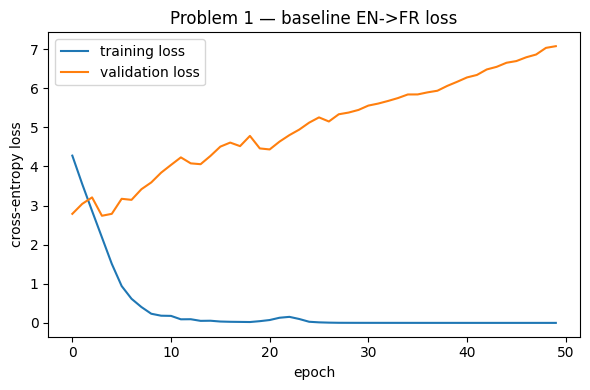

Sequence accuracy: 0.00%   BLEU-4: 0.1500


In [7]:
enc1, dec1, sl1, tl1, hist1, res1 = train_model(attn=False, direction="en-fr",
                                                label="P1 baseline EN->FR")
plot_losses(hist1, "Problem 1 — baseline EN->FR loss")
print(f"Sequence accuracy: {res1['seq_acc']*100:.2f}%   BLEU-4: {res1['bleu4']:.4f}")

**Qualitative validation (5 samples):**

In [8]:
show_samples(enc1, dec1, sl1, tl1, view('en-fr')[1], k=5)

SRC : they feed the pigeons in the square
PRED: ils nourrissent les oiseaux dans le week-end
TGT : ils nourrissent les pigeons sur la place
      exact_match=False  sentence_BLEU-4=0.193

SRC : she practices yoga every morning
PRED: elle boit du thé tous les matins
TGT : elle pratique le yoga tous les matins
      exact_match=False  sentence_BLEU-4=0.207

SRC : i enjoy walking in the snow
PRED: j'aime marcher sous la forêt dense
TGT : j'aime marcher dans la neige
      exact_match=False  sentence_BLEU-4=0.108

SRC : she loves to wear modern jackets
PRED: elle adore porter des vestes en cuir modernes
TGT : elle adore porter des vestes modernes
      exact_match=False  sentence_BLEU-4=0.541

SRC : the city bus arrives precisely at five o'clock
PRED: le bus arrive à cinq heures
TGT : le bus de la ville arrive précisément à cinq heures
      exact_match=False  sentence_BLEU-4=0.158



# Problem 2 — Encoder–Decoder with Attention (English → French)

Same architecture plus Bahdanau-style attention. Plot the losses, report both metrics,
compare with Problem 1, and visualize attention maps.

  [P2 attention EN->FR] epoch 1/50  train 4.367  val 2.763
  [P2 attention EN->FR] epoch 10/50  train 0.203  val 3.596
  [P2 attention EN->FR] epoch 20/50  train 0.163  val 4.233
  [P2 attention EN->FR] epoch 30/50  train 0.010  val 4.904
  [P2 attention EN->FR] epoch 40/50  train 0.091  val 4.924
  [P2 attention EN->FR] epoch 50/50  train 0.001  val 5.387
  [P2 attention EN->FR] seq_acc=0.000  BLEU-4=0.1514  time=572.4s


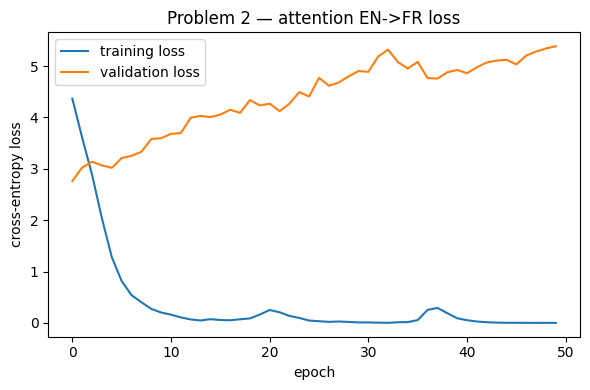

Sequence accuracy: 0.00%   BLEU-4: 0.1514


In [9]:
enc2, dec2, sl2, tl2, hist2, res2 = train_model(attn=True, direction="en-fr",
                                                label="P2 attention EN->FR")
plot_losses(hist2, "Problem 2 — attention EN->FR loss")
print(f"Sequence accuracy: {res2['seq_acc']*100:.2f}%   BLEU-4: {res2['bleu4']:.4f}")

**Baseline vs. attention (English → French):**

In [10]:
import pandas as pd
cmp = pd.DataFrame([res1, res2])[
    ["label","seq_acc","bleu4","final_train_loss","final_val_loss","train_time_s","params"]]
cmp

,label,seq_acc,bleu4,final_train_loss,final_val_loss,train_time_s,params
0,P1 baseline EN->FR,0.0,0.149955,0.000029,7.074640,395.8,1527007
1,P2 attention EN->FR,0.0,0.151446,0.000704,5.386968,572.4,1666030


**Qualitative validation (5 samples):**

In [11]:
show_samples(enc2, dec2, sl2, tl2, view('en-fr')[1], k=5)

SRC : they feed the pigeons in the square
PRED: ils nourrissent les oiseaux dans la plage
TGT : ils nourrissent les pigeons sur la place
      exact_match=False  sentence_BLEU-4=0.207

SRC : she practices yoga every morning
PRED: elle boit du lait tous les matins
TGT : elle pratique le yoga tous les matins
      exact_match=False  sentence_BLEU-4=0.207

SRC : i enjoy walking in the snow
PRED: j'aime marcher dans la forêt
TGT : j'aime marcher dans la neige
      exact_match=False  sentence_BLEU-4=0.669

SRC : she loves to wear modern jackets
PRED: elle adore porter des vestes en cuir modernes
TGT : elle adore porter des vestes modernes
      exact_match=False  sentence_BLEU-4=0.541

SRC : the city bus arrives precisely at five o'clock
PRED: le bus arrive à cinq heures
TGT : le bus de la ville arrive précisément à cinq heures
      exact_match=False  sentence_BLEU-4=0.158



**Attention maps (2 validation sentences):**

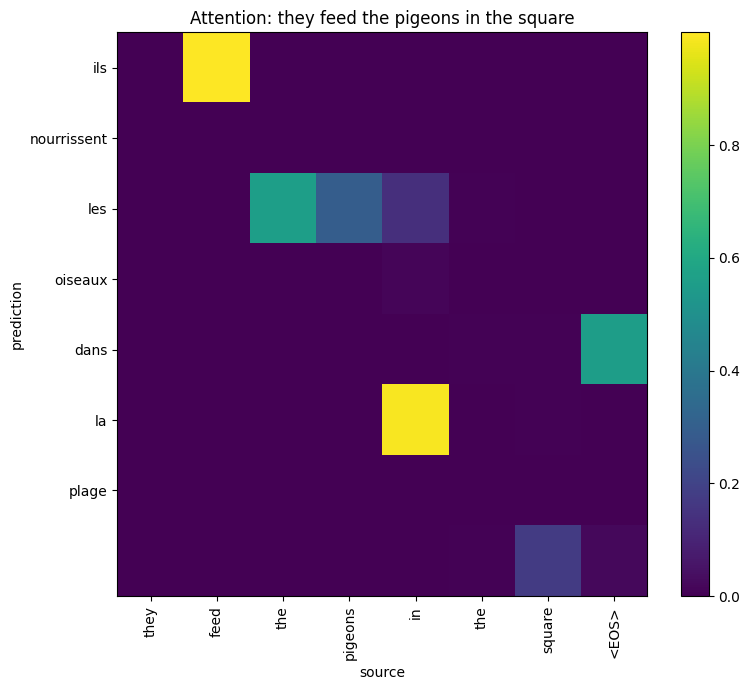

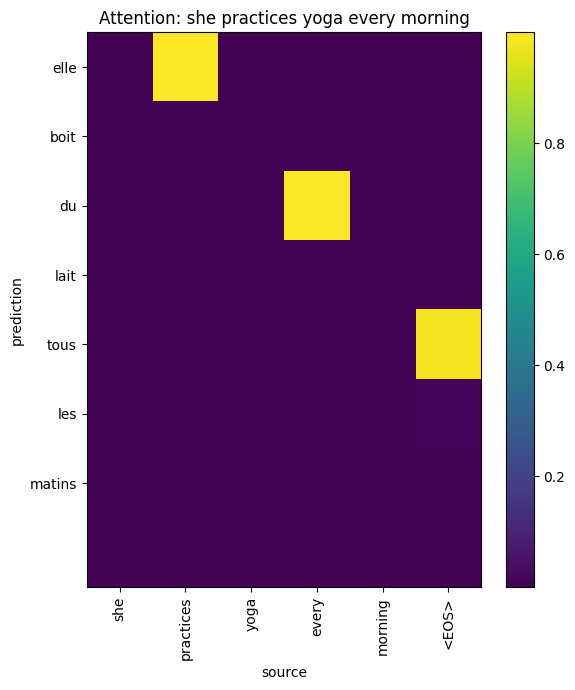

In [12]:
val_enfr = view('en-fr')[1]
show_attention(enc2, dec2, sl2, tl2, val_enfr[0][0])
show_attention(enc2, dec2, sl2, tl2, val_enfr[1][0])

# Problem 3 — Reversing the Direction (French → English)

Reuse the same split with French as source and English as target. Train **both** the
baseline and the attention model, plot losses, report both metrics, show qualitative
French→English translations, and compare the two directions.

  [P3 baseline FR->EN] epoch 1/50  train 4.228  val 3.411
  [P3 baseline FR->EN] epoch 10/50  train 0.164  val 4.135
  [P3 baseline FR->EN] epoch 20/50  train 0.039  val 5.059
  [P3 baseline FR->EN] epoch 30/50  train 0.017  val 5.293
  [P3 baseline FR->EN] epoch 40/50  train 0.287  val 5.147
  [P3 baseline FR->EN] epoch 50/50  train 0.002  val 6.040
  [P3 baseline FR->EN] seq_acc=0.000  BLEU-4=0.1328  time=398.4s


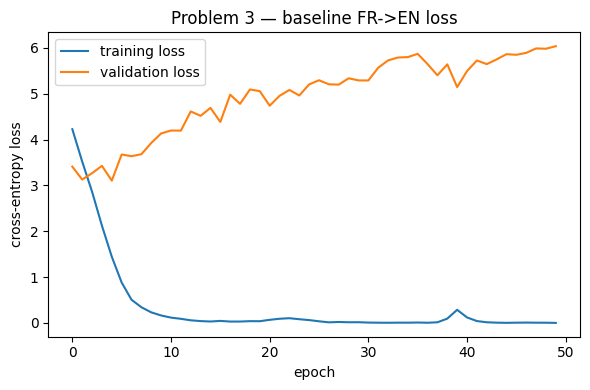

  [P3 attention FR->EN] epoch 1/50  train 4.165  val 3.083
  [P3 attention FR->EN] epoch 10/50  train 0.236  val 3.691
  [P3 attention FR->EN] epoch 20/50  train 0.319  val 4.284
  [P3 attention FR->EN] epoch 30/50  train 0.062  val 4.646
  [P3 attention FR->EN] epoch 40/50  train 0.027  val 5.223
  [P3 attention FR->EN] epoch 50/50  train 0.226  val 4.867
  [P3 attention FR->EN] seq_acc=0.000  BLEU-4=0.1088  time=567.5s


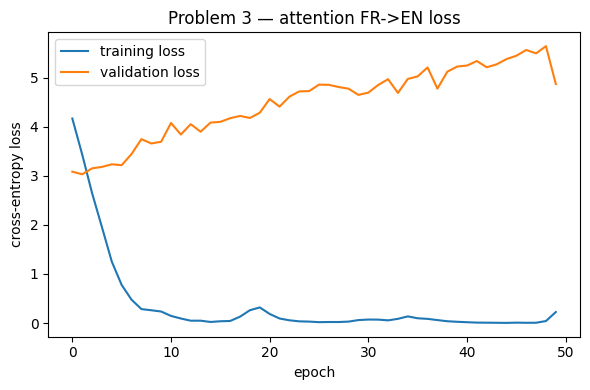

In [13]:
enc3b, dec3b, sl3b, tl3b, hist3b, res3b = train_model(attn=False, direction="fr-en",
                                                      label="P3 baseline FR->EN")
plot_losses(hist3b, "Problem 3 — baseline FR->EN loss")

enc3a, dec3a, sl3a, tl3a, hist3a, res3a = train_model(attn=True, direction="fr-en",
                                                      label="P3 attention FR->EN")
plot_losses(hist3a, "Problem 3 — attention FR->EN loss")

**Qualitative validation, French → English (attention model):**

In [14]:
show_samples(enc3a, dec3a, sl3a, tl3a, view('fr-en')[1], k=5)

SRC : ils nourrissent les pigeons sur la place
PRED: they feed the the garden
TGT : they feed the pigeons in the square
      exact_match=False  sentence_BLEU-4=0.216

SRC : elle pratique le yoga tous les matins
PRED: she paints her morning
TGT : she practices yoga every morning
      exact_match=False  sentence_BLEU-4=0.057

SRC : j'aime marcher dans la neige
PRED: i enjoy walking in the dense
TGT : i enjoy walking in the snow
      exact_match=False  sentence_BLEU-4=0.760

SRC : elle adore porter des vestes modernes
PRED: she teaches complex warm winter
TGT : she loves to wear modern jackets
      exact_match=False  sentence_BLEU-4=0.037

SRC : le bus de la ville arrive précisément à cinq heures
PRED: the bus arrives at five o'clock o'clock o'clock
TGT : the city bus arrives precisely at five o'clock
      exact_match=False  sentence_BLEU-4=0.217



**All four models side by side:**

In [15]:
summary = pd.DataFrame([res1, res2, res3b, res3a])[
    ["label","direction","attention","seq_acc","bleu4",
     "final_train_loss","final_val_loss","train_time_s"]]
summary

,label,direction,attention,seq_acc,bleu4,final_train_loss,final_val_loss,train_time_s
0,P1 baseline EN->FR,en-fr,False,0.0,0.149955,0.000029,7.074640,395.8
1,P2 attention EN->FR,en-fr,True,0.0,0.151446,0.000704,5.386968,572.4
2,P3 baseline FR->EN,fr-en,False,0.0,0.132798,0.002252,6.039611,398.4
3,P3 attention FR->EN,fr-en,True,0.0,0.108770,0.225729,4.867415,567.5


In [16]:
# direction comparison: average final validation loss / BLEU per direction
for d in ["en-fr", "fr-en"]:
    rows = [r for r in [res1, res2, res3b, res3a] if r["direction"] == d]
    avg_val = sum(r["final_val_loss"] for r in rows) / len(rows)
    avg_bleu = sum(r["bleu4"] for r in rows) / len(rows)
    avg_acc = sum(r["seq_acc"] for r in rows) / len(rows)
    print(f"{d}:  avg val loss {avg_val:.3f} | avg BLEU-4 {avg_bleu:.4f} | "
          f"avg seq acc {avg_acc*100:.2f}%")

en-fr:  avg val loss 6.231 | avg BLEU-4 0.1507 | avg seq acc 0.00%
fr-en:  avg val loss 5.454 | avg BLEU-4 0.1208 | avg seq acc 0.00%
